# **Campus Placement Prediction** | Random Forest, 2025

# **I. Data Understanding**

# ***A. Penjabaran Studi Kasus***

# ***B. Import Libraries***

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tkinter as tk

# ***C. Import Dataset***

In [3]:
dataset = pd.read_csv("CollegePlacement.csv")
dataset

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No
...,...,...,...,...,...,...,...,...,...,...
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No


# **II. Data Preparation**

# ***A. Exploratory Data Analysis***

### 1. Inspeksi Daftar Variabel

In [4]:
dataset.columns

Index(['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='str')

penjelasan variabel :
1. College_ID = id sekolah
2. IQ = Skor Intelligence Quotient mahasiswa
3. Prev_Sem_Result = preview nilai-nilai mahasiswa semester lalu
4. CGPA = Cumulative Grade Point Average
5. Academic_Performance = performa akademik keseluruhan
6. Internship_Experience = pernah magang atau tidak
7. Extra_Curricular_Score = nilai mata pelajaran tambahan
8. Communication_Skills = skil berbicara dengan orang lain/di umum
9. Projects_Completed = projek yang terselesaikan
10. Placement = penempatan sekolah/jurusan

### 2. Inspeksi Informasi Ringkas

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  str    
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  str    
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  str    
dtypes: float64(2), int64(5), str(3)
memory usage: 781.4 KB


In [6]:
num_cols = ['IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance', 'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed']
ordinal_cols = ['Internship_Experience', 'Placement']
all_cols = ['IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement']
all_feature = ['IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed']
target_col = ['Placement']

### 3. Inspeksi Statistik Deskriptif

In [7]:
dataset.describe()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


### 4. Inspeksi Data NaN

In [8]:
dataset.isna().sum()

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

### 5. Inspeksi Data Duplicated

In [9]:
dataset.duplicated().sum()

np.int64(0)

### 6. Data Encoding

In [10]:
map_yesno = {"Yes" : 0, "No" : 1}
dataset[ordinal_cols] = dataset[ordinal_cols].replace(map_yesno)

### 7. Univariate Analysis

In [11]:
target_count = dataset['Placement'].value_counts()
target_count

Placement
1    8341
0    1659
Name: count, dtype: int64

#### *a. Inspeksi Distribusi Kelas Target*

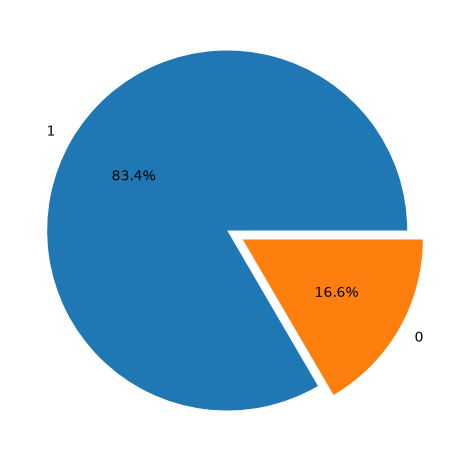

In [12]:
explode = [0.05] * len(target_count)
plt.pie(target_count, labels=target_count.index, autopct="%1.1f%%", explode=explode)
plt.tight_layout()
plt.show()

#### *b. Inspeksi Distribusi Kelas Fitur*

In [13]:
def check_value(dataset, cols, top_n=1):
    for col in cols:
        print(dataset[col].value_counts().head(top_n))
        print("\n")
check_value(dataset, all_feature, top_n=1)

IQ
99    288
Name: count, dtype: int64


Prev_Sem_Result
8.41    35
Name: count, dtype: int64


CGPA
9.41    35
Name: count, dtype: int64


Academic_Performance
10    1044
Name: count, dtype: int64


Internship_Experience
1    6036
Name: count, dtype: int64


Extra_Curricular_Score
3    965
Name: count, dtype: int64


Communication_Skills
10    1103
Name: count, dtype: int64


Projects_Completed
5    1702
Name: count, dtype: int64




### 8. Bivariate Analysis

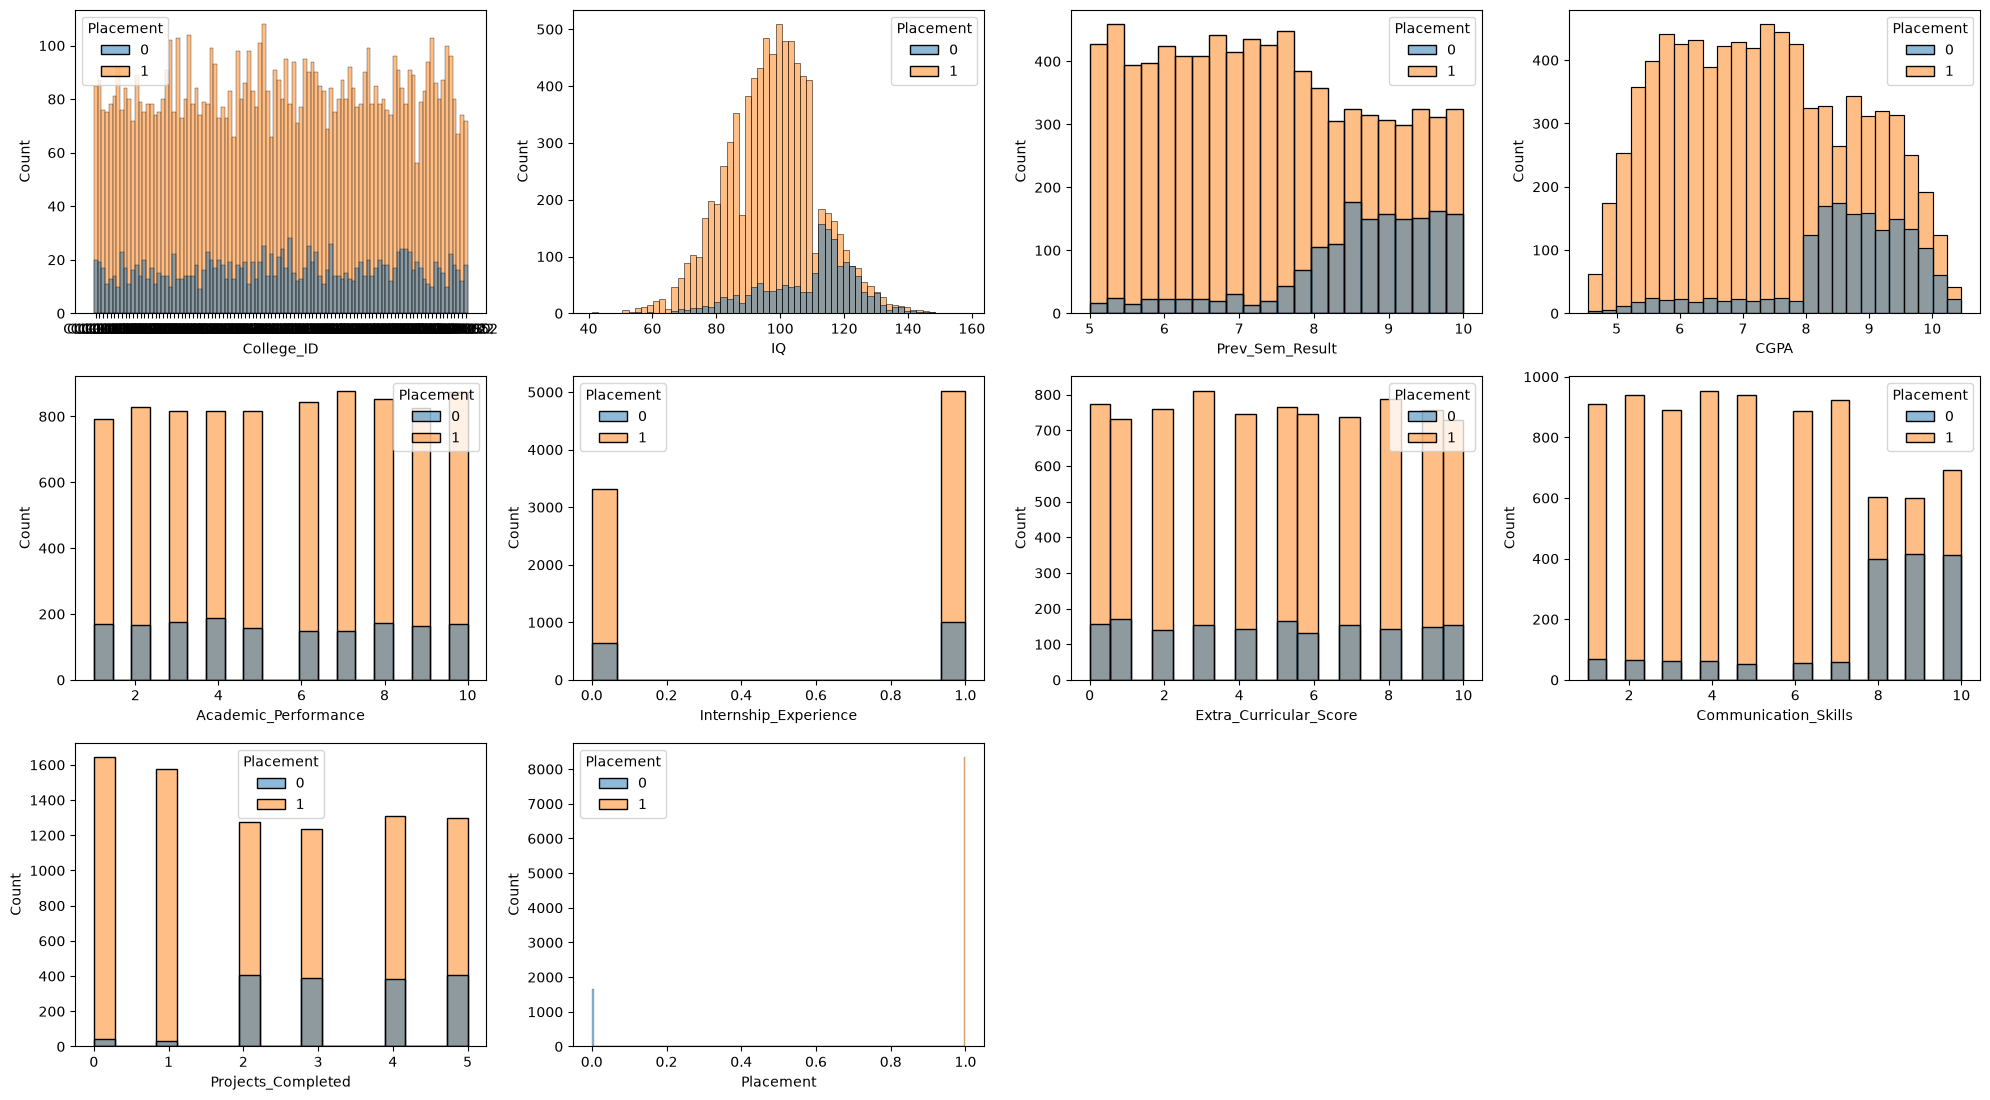

In [14]:
def bivariate_analysis(p, l, dataset, target_col, p_col, l_col, title):
    plt.figure(figsize=(20,18))
    for i, col in enumerate(dataset):
        plt.subplot(5, 4, i+1)
        sns.histplot(x=dataset[col], hue=dataset['Placement'])
    plt.tight_layout()
    plt.show()

bivariate_analysis(20, 18, dataset, target_col, 4, 5, "Distribusi Setiap Fitur dengan Target")

### 9. Multivariate Analysis

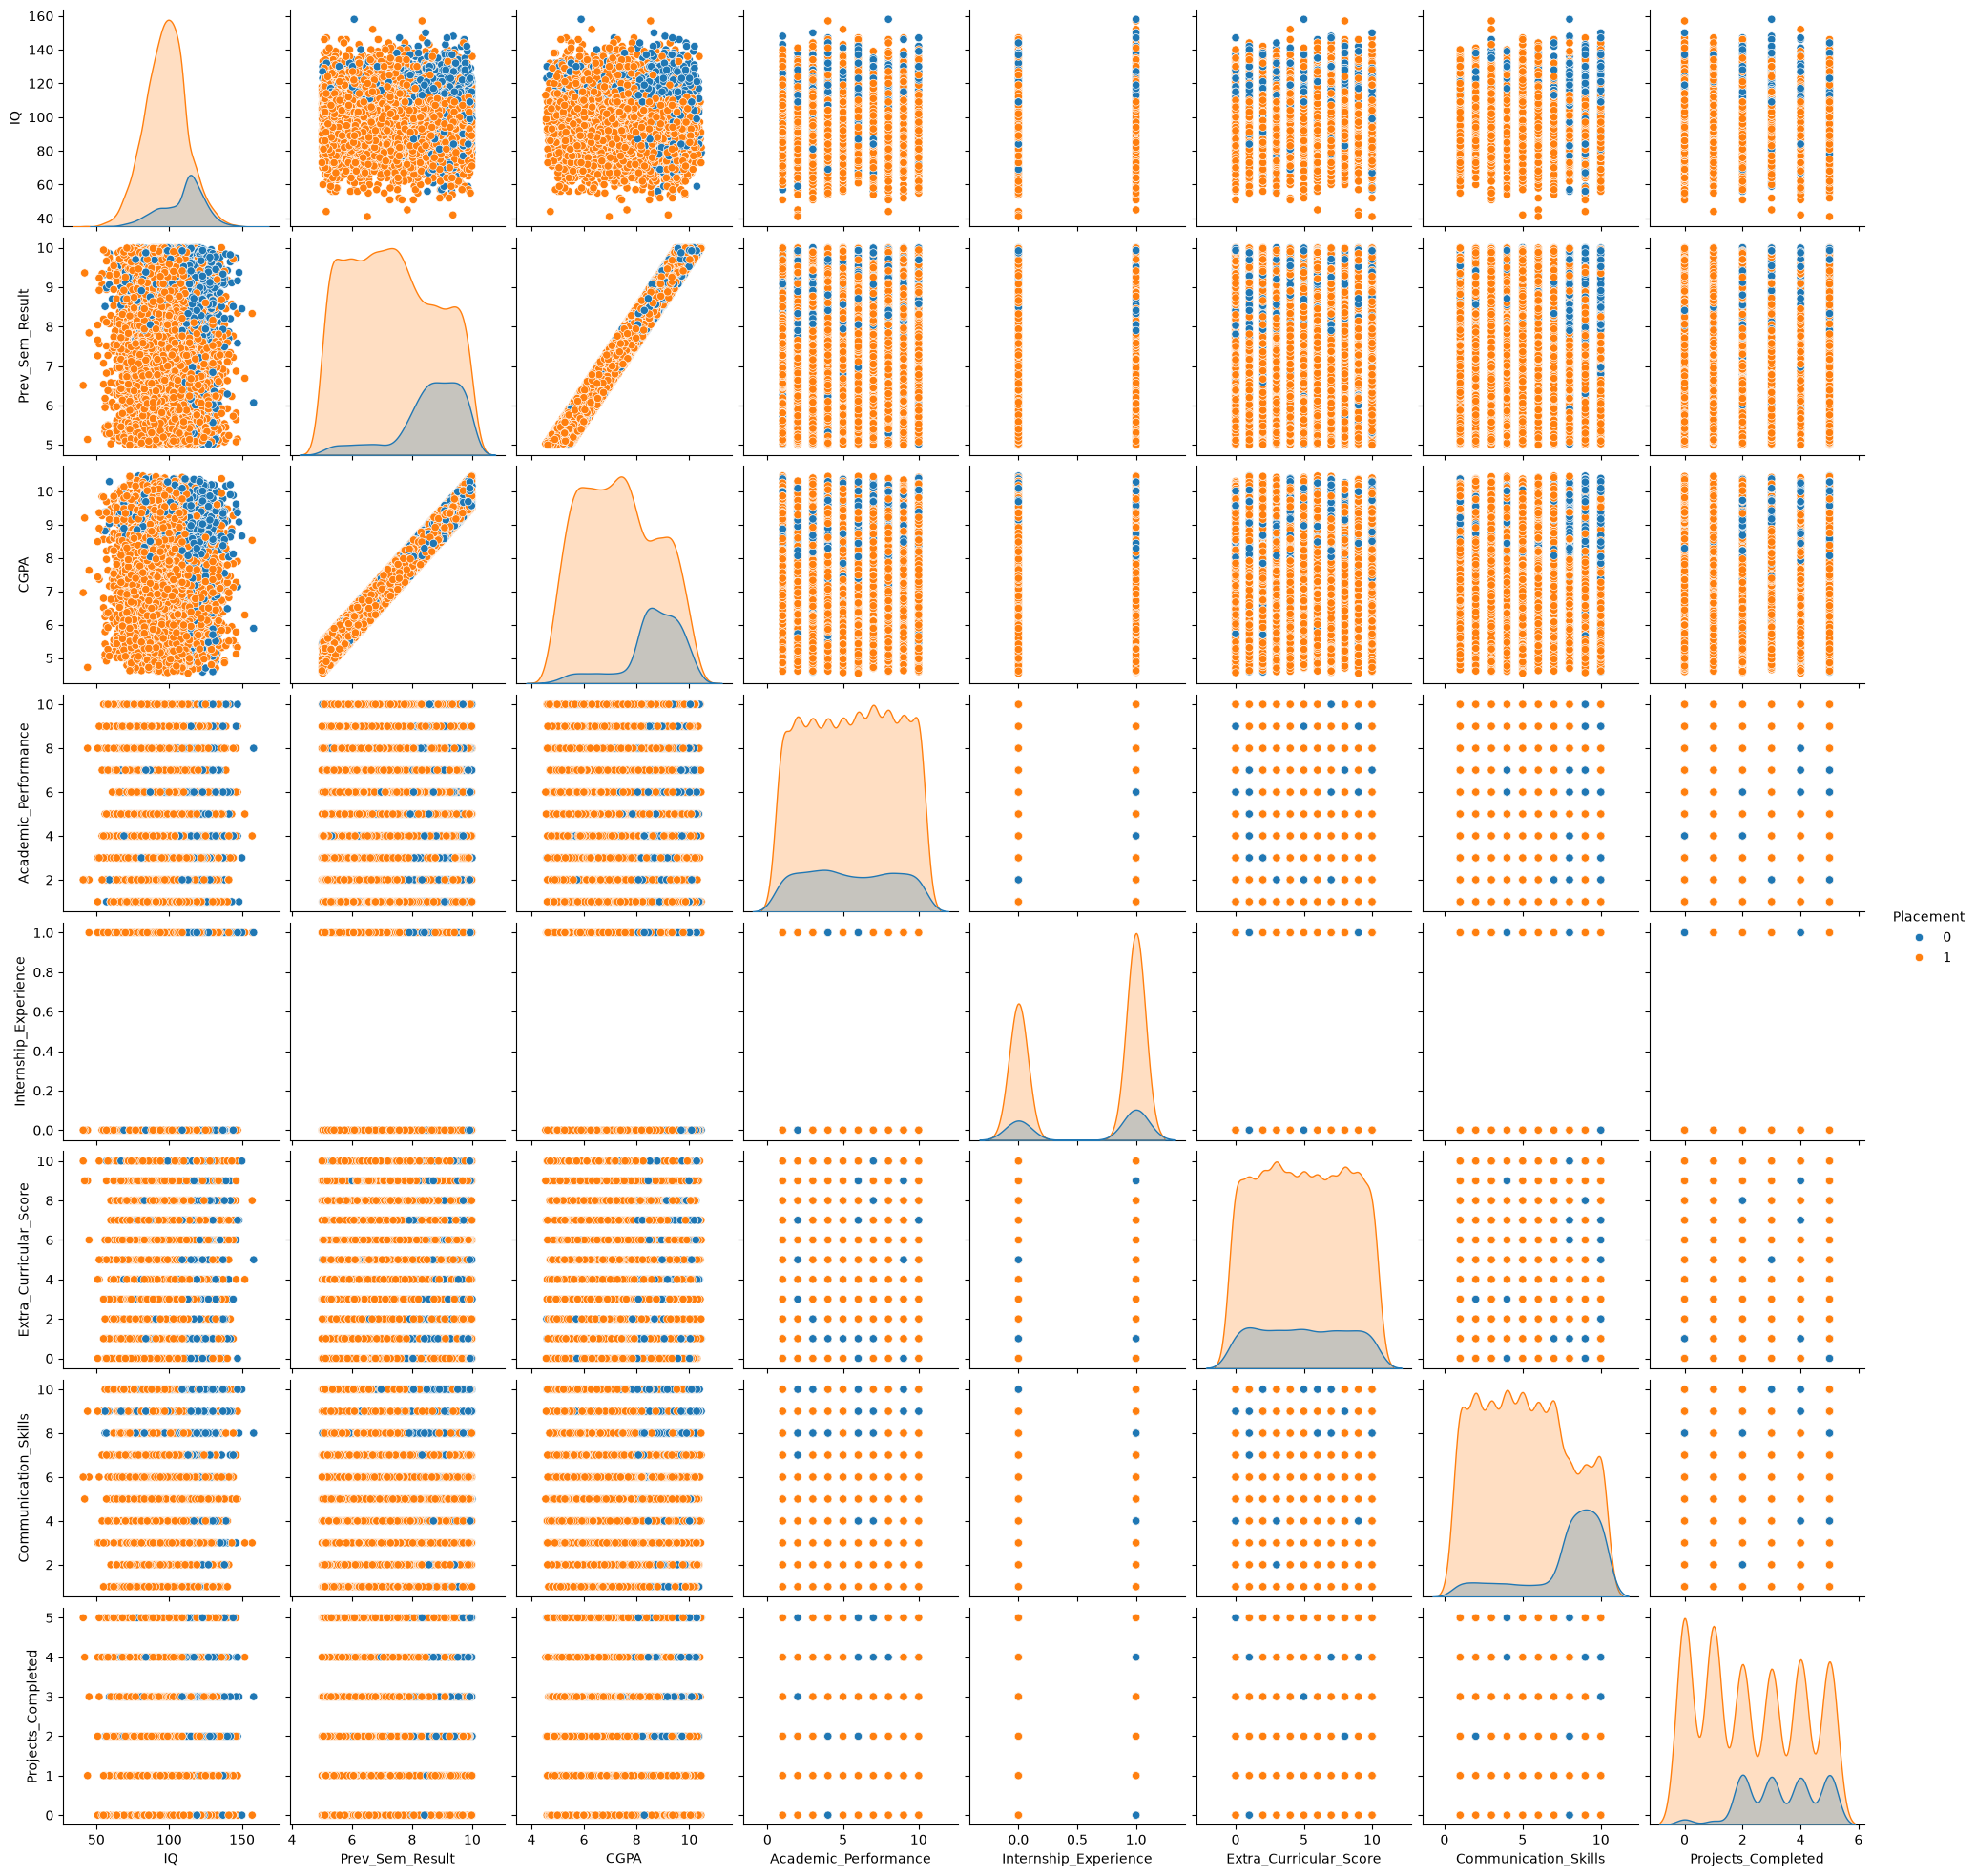

In [15]:
sns.pairplot(dataset, hue='Placement')

### 10. Inspeksi Korelasi

#### *a. Mutual Information*

In [16]:
def probability_distribution(x):
    unique, counts = np.unique(x, return_counts=True)
    return counts / counts.sum()

def calculate_entropy(x):
    probs = probability_distribution(x)
    return -np.sum(probs * np.log2(probs + 1e-10))

def mutual_information(x, y):
    xy_pairs = list(zip(x, y))
    unique_xy, counts_xy = np.unique(xy_pairs, return_counts=True)
    probs_xy = counts_xy / counts_xy.sum()
    entropy_xy = -np.sum(probs_xy * np.log2(probs_xy + 1e-10))
    entropy_x = calculate_entropy(x)
    entropy_y = calculate_entropy(y)
    return entropy_x + entropy_y - entropy_xy

def mi_result(p, l, fitur, target, title):
    fitur = dataset[all_feature]
    target = dataset['Placement']
    mi_scores = {col: mutual_information(fitur[col].values, target.values) for col in fitur.columns}
    mi_df = pd.DataFrame(list(mi_scores.items()), columns=['Feature', 'Mutual Information'])
    mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)

    plt.figure(figsize=(12,8))
    sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
    plt.xlabel("Mutual Information")
    plt.ylabel("Feature")
    plt.title(title)
    plt.legend()
    plt.show()

C:\Users\nizam\AppData\Local\Temp\ipykernel_11088\563907439.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
C:\Users\nizam\AppData\Local\Temp\ipykernel_11088\563907439.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


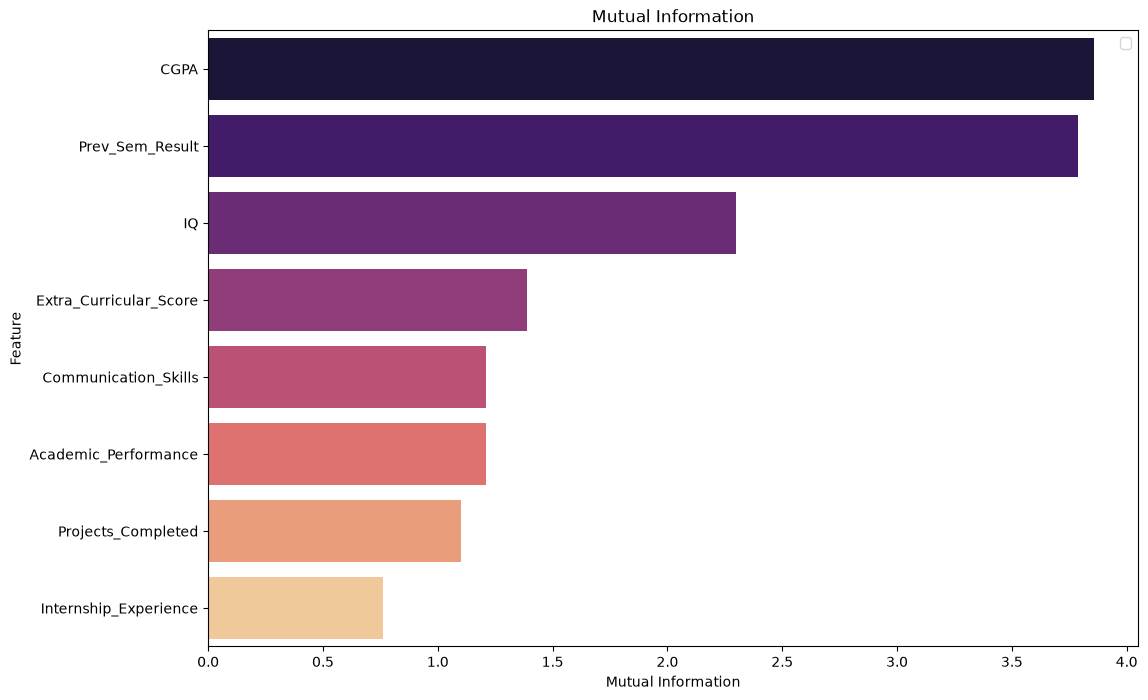

In [17]:
mi_result(12, 8, dataset[all_feature], dataset[target_col], "Mutual Information")

### 11. Inspeksi Outlier

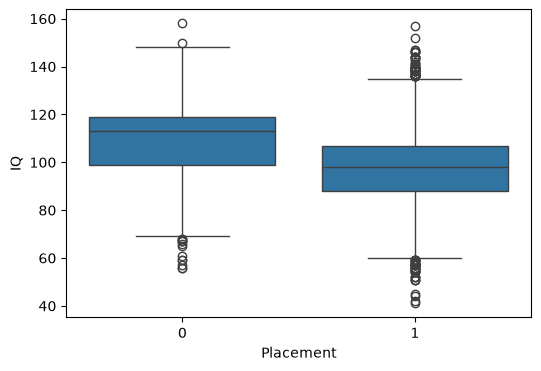

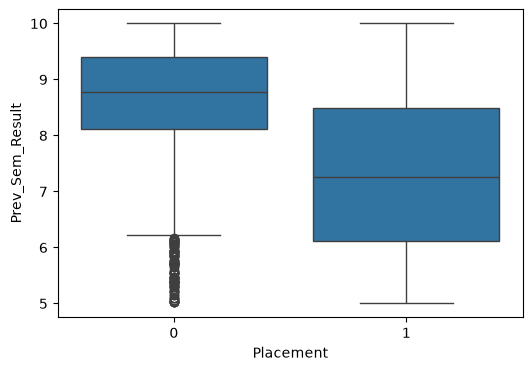

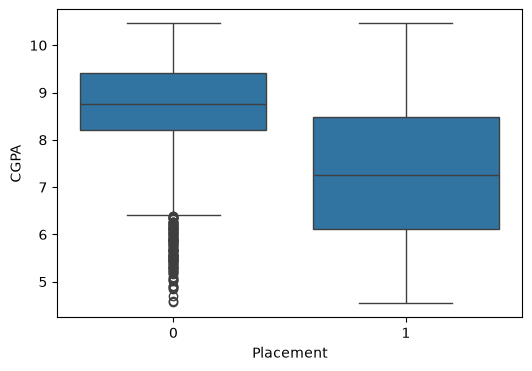

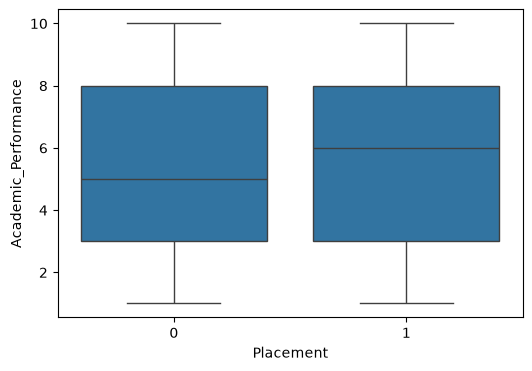

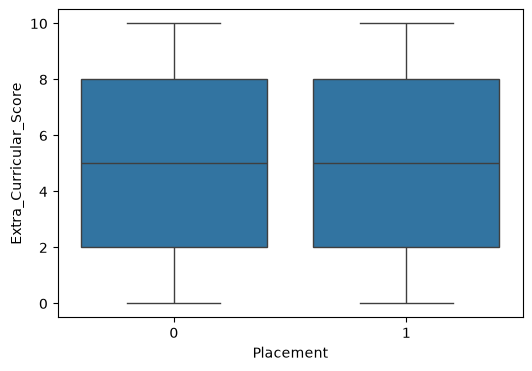

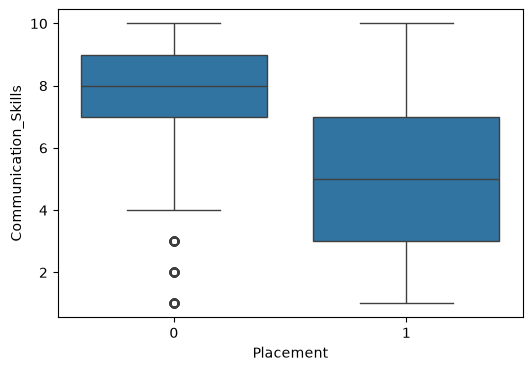

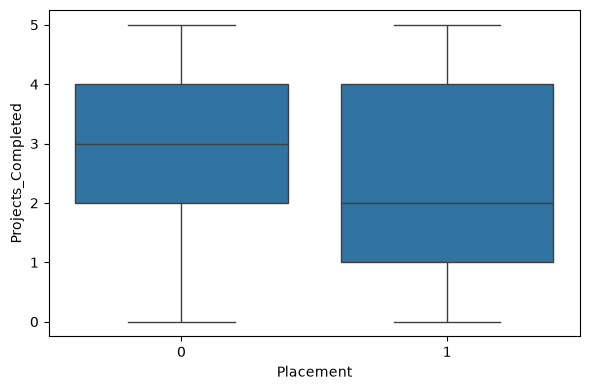

In [18]:
for col in num_cols:
    if col in dataset.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=dataset, x='Placement', y=col)  
plt.tight_layout()
plt.show()

# ***B. Feature Selection***

In [19]:
feature_cols = ['CGPA', 'Prev_Sem_Result', 'IQ', 'Extra_Curricular_Score']

# ***C. Data Preprocessing***

# ***D. Splitting Dataset***

In [20]:
def stratified_split(dataset, target_column, training_size=0.8, random_state=42):
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_value in dataset[target_column].unique():
        class_data = dataset[dataset[target_column] == class_value]
        class_data = class_data.sample(frac=1, random_state=random_state)

        split_idx = int(len(class_data) * training_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data.iloc[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataset_training, dataset_testing = stratified_split(dataset, 'Placement')

# ***E. Data Sampling***

In [21]:
# Cek nilai unik di kolom Placement
print("=== CEK KOLOM PLACEMENT ===")
print(f"Nilai unik: {dataset['Placement'].unique()}")
print(f"Tipe data: {dataset['Placement'].dtype}")
print(f"\nValue counts:")
print(dataset['Placement'].value_counts())

=== CEK KOLOM PLACEMENT ===
Nilai unik: [1 0]
Tipe data: object

Value counts:
Placement
1    8341
0    1659
Name: count, dtype: int64


In [22]:
def manual_oversample(df, target_col, random_state=42):
    np.random.seed(random_state)
    
    # Hitung masing-masing kelas
    value_counts = df[target_col].value_counts()
    
    # Ambil kelas mayoritas dan minoritas
    majority_class = value_counts.idxmax()  # 1
    minority_class = value_counts.idxmin()  # 0
    
    df_majority = df[df[target_col] == majority_class]
    df_minority = df[df[target_col] == minority_class]
    
    n_majority = len(df_majority)
    n_minority = len(df_minority)
    
    print(f"Sebelum:")
    print(f"  Kelas {majority_class} (mayoritas): {n_majority}")
    print(f"  Kelas {minority_class} (minoritas): {n_minority}")
    
    # Tambah data minoritas
    n_tambah = n_majority - n_minority
    idx_random = np.random.choice(df_minority.index, size=n_tambah, replace=True)
    df_tambahan = df_minority.loc[idx_random]
    
    # Gabungkan
    df_balanced = pd.concat([df_majority, df_minority, df_tambahan], ignore_index=True)
    
    # Shuffle
    df_balanced = df_balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    print(f"\nSesudah:")
    print(df_balanced[target_col].value_counts())
    
    return df_balanced

# Apply
dataset_balanced = manual_oversample(dataset, 'Placement')

Sebelum:
  Kelas 1 (mayoritas): 8341
  Kelas 0 (minoritas): 1659

Sesudah:
Placement
1    8341
0    8341
Name: count, dtype: int64


# ***F. Feature Target Declaration***

In [23]:
X_train = dataset_training[feature_cols].to_numpy()
X_test = dataset_testing[feature_cols].to_numpy()
y_train = dataset_training['Placement'].to_numpy()
y_test = dataset_testing['Placement'].to_numpy()

# **III. Modeling**

# ***A. Model Application***

### 1. Model dengan Class

In [24]:
class RandomForest:
    def __init__(self, n_trees=10, max_depth=5, min_samples=2, 
                 min_samples_split=None, min_samples_leaf=1,
                 sample_ratio=1.0, feature_ratio=None, 
                 feature_names=None, mode="ensemble"):
        
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples = min_samples_split if min_samples_split else min_samples
        self.min_samples_leaf = min_samples_leaf
        self.sample_ratio = sample_ratio
        self.feature_ratio = feature_ratio
        self.feature_names = feature_names
        self.mode = mode
        self.trees = []
    
    # ============ HELPER FUNCTIONS ============
    
    def most_common(self, y):
        """Cari nilai yang paling sering muncul"""
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]
    
    def gini(self, y):
        """Hitung Gini Impurity"""
        if len(y) == 0:
            return 0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)
    
    def split_data(self, X, y, feature, threshold):
        """Split data berdasarkan threshold"""
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        return X[left_mask], X[right_mask], y[left_mask], y[right_mask]
    
    # ============ FIND BEST SPLIT ============
    
    def best_split(self, X, y, feature_indices):
        """Cari split terbaik"""
        best_gain = -1
        best_feature = None
        best_threshold = None
        
        parent_gini = self.gini(y)
        
        for feature in feature_indices:
            thresholds = np.unique(X[:, feature])
            
            for threshold in thresholds:
                _, _, y_left, y_right = self.split_data(X, y, feature, threshold)
                
                # Check min_samples_leaf constraint
                if len(y_left) < self.min_samples_leaf or len(y_right) < self.min_samples_leaf:
                    continue
                
                # Hitung information gain
                n = len(y)
                n_left, n_right = len(y_left), len(y_right)
                child_gini = (n_left/n) * self.gini(y_left) + (n_right/n) * self.gini(y_right)
                gain = parent_gini - child_gini
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_gain
    
    # ============ BUILD TREE ============
    
    def build_tree(self, X, y, depth=0):
        """Bangun decision tree secara rekursif"""
        
        # Stopping conditions
        if len(np.unique(y)) == 1:
            return self.most_common(y)
        
        if depth >= self.max_depth or len(y) < self.min_samples:
            return self.most_common(y)
        
        # Random feature selection
        if self.feature_ratio:
            n_features = max(1, int(self.feature_ratio * X.shape[1]))
        else:
            n_features = max(1, int(np.sqrt(X.shape[1])))
        
        feature_indices = np.random.choice(X.shape[1], n_features, replace=False)
        
        # Cari split terbaik
        feature, threshold, gain = self.best_split(X, y, feature_indices)
        
        if feature is None:
            return self.most_common(y)
        
        # Split dan rekursi
        X_left, X_right, y_left, y_right = self.split_data(X, y, feature, threshold)
        
        return {
            'feature': feature,
            'threshold': threshold,
            'left': self.build_tree(X_left, y_left, depth + 1),
            'right': self.build_tree(X_right, y_right, depth + 1)
        }
    
    # ============ FIT (TRAINING) ============
    
    def fit(self, X, y):
        """Training Random Forest"""
        self.trees = []
        n_samples = len(X)
        
        # Calculate bootstrap sample size
        bootstrap_size = int(self.sample_ratio * n_samples)
        
        for i in range(self.n_trees):
            # Bootstrap sampling
            idx = np.random.choice(n_samples, bootstrap_size, replace=True)
            X_sample, y_sample = X[idx], y[idx]
            
            # Bangun tree
            tree = self.build_tree(X_sample, y_sample)
            self.trees.append(tree)
            
            if (i + 1) % 5 == 0:
                print(f"Tree {i+1}/{self.n_trees} selesai")
        
        print("Training selesai!")
        return self
    
    # ============ PREDICT ============
    
    def predict_one(self, tree, x):
        """Prediksi 1 sampel dengan 1 tree"""
        if not isinstance(tree, dict):
            return tree
        
        if x[tree['feature']] <= tree['threshold']:
            return self.predict_one(tree['left'], x)
        else:
            return self.predict_one(tree['right'], x)
    
    def predict(self, X):
        """Prediksi semua sampel"""
        predictions = []
        
        for x in X:
            tree_preds = [self.predict_one(tree, x) for tree in self.trees]
            final_pred = self.most_common(np.array(tree_preds))
            predictions.append(final_pred)
        
        return np.array(predictions)
    
    # ============ PREDICT PROBA ============
    
    def predict_proba(self, X):
        """Prediksi probabilitas"""
        probas = []
        
        for x in X:
            tree_preds = [self.predict_one(tree, x) for tree in self.trees]
            prob_1 = np.mean(tree_preds)
            probas.append([1 - prob_1, prob_1])
        
        return np.array(probas)
    
    # ============ FEATURE IMPORTANCE ============
    
    def feature_importance(self):
        """Hitung feature importance berdasarkan frekuensi penggunaan"""
        importance = {}
        
        def count_features(tree):
            if not isinstance(tree, dict):
                return
            feature = tree['feature']
            importance[feature] = importance.get(feature, 0) + 1
            count_features(tree['left'])
            count_features(tree['right'])
        
        for tree in self.trees:
            count_features(tree)
        
        # Normalize
        total = sum(importance.values()) if importance else 1
        importance = {k: v/total for k, v in importance.items()}
        
        # Sort
        importance = dict(sorted(importance.items(), key=lambda x: x[1], reverse=True))
        
        # Use feature names if available
        if self.feature_names is not None:
            importance = {self.feature_names[k]: v for k, v in importance.items()}
        
        return importance
    
    # ============ VISUALISASI POHON ============
    
    def visualize_tree(self, tree_index=0, figsize=(20, 10)):
        """
        Visualisasi satu pohon dari Random Forest
        
        Parameters:
        - tree_index: index pohon yang ingin divisualisasi (0 sampai n_trees-1)
        - figsize: ukuran figure
        """
        if tree_index >= len(self.trees):
            print(f"Error: Hanya ada {len(self.trees)} pohon. Index harus 0-{len(self.trees)-1}")
            return
        
        tree = self.trees[tree_index]
        
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
        ax.set_title(f'Decision Tree #{tree_index + 1}', fontsize=16, fontweight='bold')
        
        self._draw_tree(ax, tree, x=0.5, y=0.95, dx=0.25, level=0)
        
        plt.tight_layout()
        plt.show()
    
    def _get_feature_name(self, feature_idx):
        """Dapatkan nama fitur"""
        if self.feature_names is not None:
            return self.feature_names[feature_idx]
        return f"Feature {feature_idx}"
    
    def _draw_tree(self, ax, node, x, y, dx, level):
        """Gambar pohon secara rekursif"""
        
        # Warna berdasarkan level
        colors = ['#E8F5E9', '#C8E6C9', '#A5D6A7', '#81C784', '#66BB6A', '#4CAF50']
        box_color = colors[min(level, len(colors)-1)]
        
        if not isinstance(node, dict):
            # Leaf node
            bbox = dict(boxstyle='round,pad=0.3', facecolor='#FFCDD2', edgecolor='#D32F2F', linewidth=2)
            ax.text(x, y, f'Prediksi:\n{node}', ha='center', va='center', 
                   fontsize=10, fontweight='bold', bbox=bbox)
            return
        
        # Internal node
        feature_name = self._get_feature_name(node['feature'])
        bbox = dict(boxstyle='round,pad=0.3', facecolor=box_color, edgecolor='#388E3C', linewidth=2)
        ax.text(x, y, f'{feature_name}\n≤ {node["threshold"]:.3f}', 
               ha='center', va='center', fontsize=9, bbox=bbox)
        
        # Hitung posisi anak
        new_dx = dx * 0.6
        y_child = y - 0.15
        
        # Gambar garis ke anak kiri
        x_left = x - dx
        ax.annotate('', xy=(x_left, y_child + 0.04), xytext=(x - 0.02, y - 0.04),
                   arrowprops=dict(arrowstyle='->', color='#1976D2', lw=1.5))
        ax.text((x + x_left)/2 - 0.02, (y + y_child)/2, 'Ya', fontsize=8, color='#1976D2')
        
        # Gambar garis ke anak kanan  
        x_right = x + dx
        ax.annotate('', xy=(x_right, y_child + 0.04), xytext=(x + 0.02, y - 0.04),
                   arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=1.5))
        ax.text((x + x_right)/2 + 0.02, (y + y_child)/2, 'Tidak', fontsize=8, color='#D32F2F')
        
        # Rekursi ke anak
        self._draw_tree(ax, node['left'], x_left, y_child, new_dx, level + 1)
        self._draw_tree(ax, node['right'], x_right, y_child, new_dx, level + 1)
    
    def visualize_all_trees(self, max_trees=6, figsize=(15, 10)):
        """
        Visualisasi beberapa pohon sekaligus
        
        Parameters:
        - max_trees: maksimal pohon yang ditampilkan
        - figsize: ukuran figure
        """
        n_show = min(max_trees, len(self.trees))
        
        # Tentukan layout grid
        if n_show <= 2:
            rows, cols = 1, n_show
        elif n_show <= 4:
            rows, cols = 2, 2
        else:
            rows, cols = 2, 3
        
        fig, axes = plt.subplots(rows, cols, figsize=figsize)
        if n_show == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
        
        for i in range(n_show):
            ax = axes[i]
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.axis('off')
            ax.set_title(f'Tree #{i + 1}', fontsize=12, fontweight='bold')
            self._draw_tree(ax, self.trees[i], x=0.5, y=0.9, dx=0.2, level=0)
        
        # Sembunyikan axes yang tidak dipakai
        for i in range(n_show, len(axes)):
            axes[i].axis('off')
        
        plt.suptitle('Random Forest - Visualisasi Pohon', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    def print_tree(self, tree_index=0):
        """
        Print struktur pohon dalam format text
        
        Parameters:
        - tree_index: index pohon yang ingin diprint
        """
        if tree_index >= len(self.trees):
            print(f"Error: Hanya ada {len(self.trees)} pohon.")
            return
        
        print(f"\n{'='*50}")
        print(f"STRUKTUR TREE #{tree_index + 1}")
        print(f"{'='*50}")
        self._print_tree_recursive(self.trees[tree_index], indent=0)
    
    def _print_tree_recursive(self, node, indent=0):
        """Print pohon secara rekursif"""
        prefix = "  " * indent
        
        if not isinstance(node, dict):
            print(f"{prefix}🍃 PREDIKSI: {node}")
            return
        
        feature_name = self._get_feature_name(node['feature'])
        print(f"{prefix}📍 {feature_name} <= {node['threshold']:.4f}")
        print(f"{prefix}├── Ya (kiri):")
        self._print_tree_recursive(node['left'], indent + 1)
        print(f"{prefix}└── Tidak (kanan):")
        self._print_tree_recursive(node['right'], indent + 1)
    
    def print_all_trees(self):
        """Print semua pohon"""
        for i in range(len(self.trees)):
            self.print_tree(i)

### 2. Pengaplikasian Model

In [25]:
# rf = RandomForest(n_trees=10, max_depth=5, min_samples=3)
# rf.fit(X_train, y_train)
# y_pred = rf.predict(X_test)

In [26]:
rf = RandomForest(
    mode="ensemble",
    n_trees=15,
    max_depth=4,
    min_samples_split=3,
    min_samples_leaf=2,
    sample_ratio=0.8,
    feature_ratio=0.7,
    feature_names=feature_cols
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

Tree 5/15 selesai
Tree 10/15 selesai
Tree 15/15 selesai
Training selesai!


In [27]:
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# ***B. Visualisasi Model***

### 1. Distribusi Hasil Prediksi

#### *a. Training Model*

In [28]:
data_pred_train = pd.DataFrame({
    "Random Forest Model": y_pred_train,
    "Training Actual": y_train
})

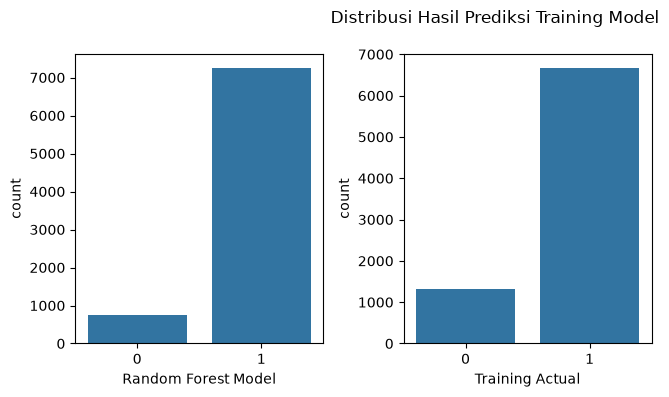

In [29]:
plt.figure(figsize=(10,4))
for i, col in enumerate(data_pred_train):
    plt.subplot(1, 3, i+1)
    sns.countplot(x=data_pred_train[col])
plt.suptitle("Distribusi Hasil Prediksi Training Model")
plt.tight_layout()
plt.show()

#### *b. Testing Model*

In [30]:
data_pred_test = pd.DataFrame({
    "Random Forest Model": y_pred_test,
    "Test Actual": y_test
})

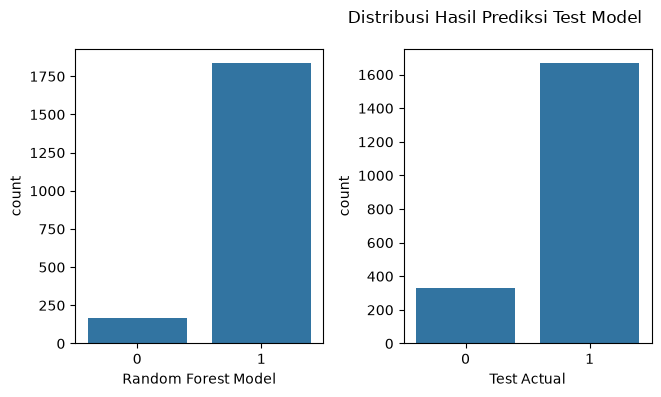

In [31]:
plt.figure(figsize=(10,4))
for i, col in enumerate(data_pred_test):
    plt.subplot(1, 3, i+1)
    sns.countplot(x=data_pred_test[col])
plt.suptitle("Distribusi Hasil Prediksi Test Model")
plt.tight_layout()
plt.show()

### 2. Confusion Matrix

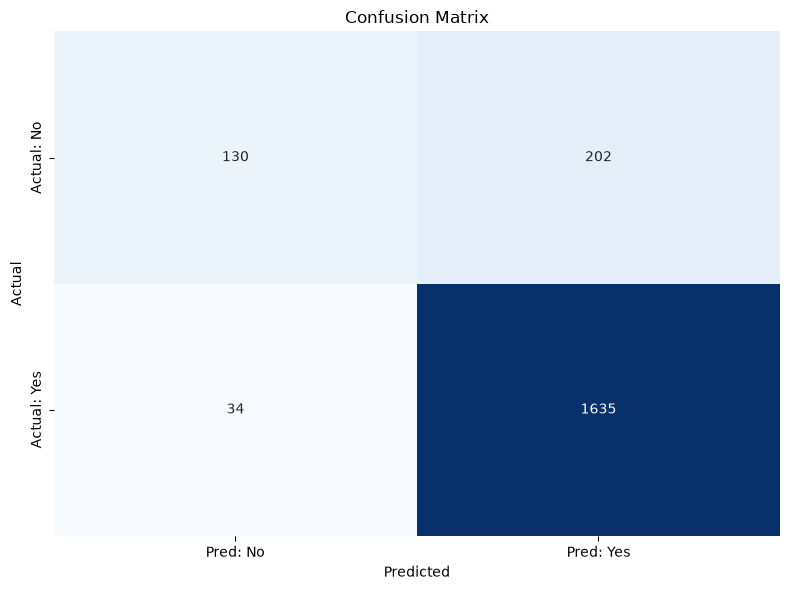

In [32]:
unique_labels = np.unique(np.concatenate([y_test, y_pred_test]))
if len(unique_labels) == 2:
    cm = np.zeros((2, 2), dtype=int)
    for true, pred in zip(y_test, y_pred_test):
        cm[true, pred] += 1
else:
    cm = np.array([[len(y_test)]]) if unique_labels[0] == 0 else np.array([[0, len(y_test)]]) if unique_labels[0] == 1 else np.array([[len(y_test), 0]])

cm_df = pd.DataFrame(
    cm,
    index=['Actual: No', 'Actual: Yes'][:cm.shape[0]],
    columns=['Pred: No', 'Pred: Yes'][:cm.shape[1]]
)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### 3. Visualisasi Pohon

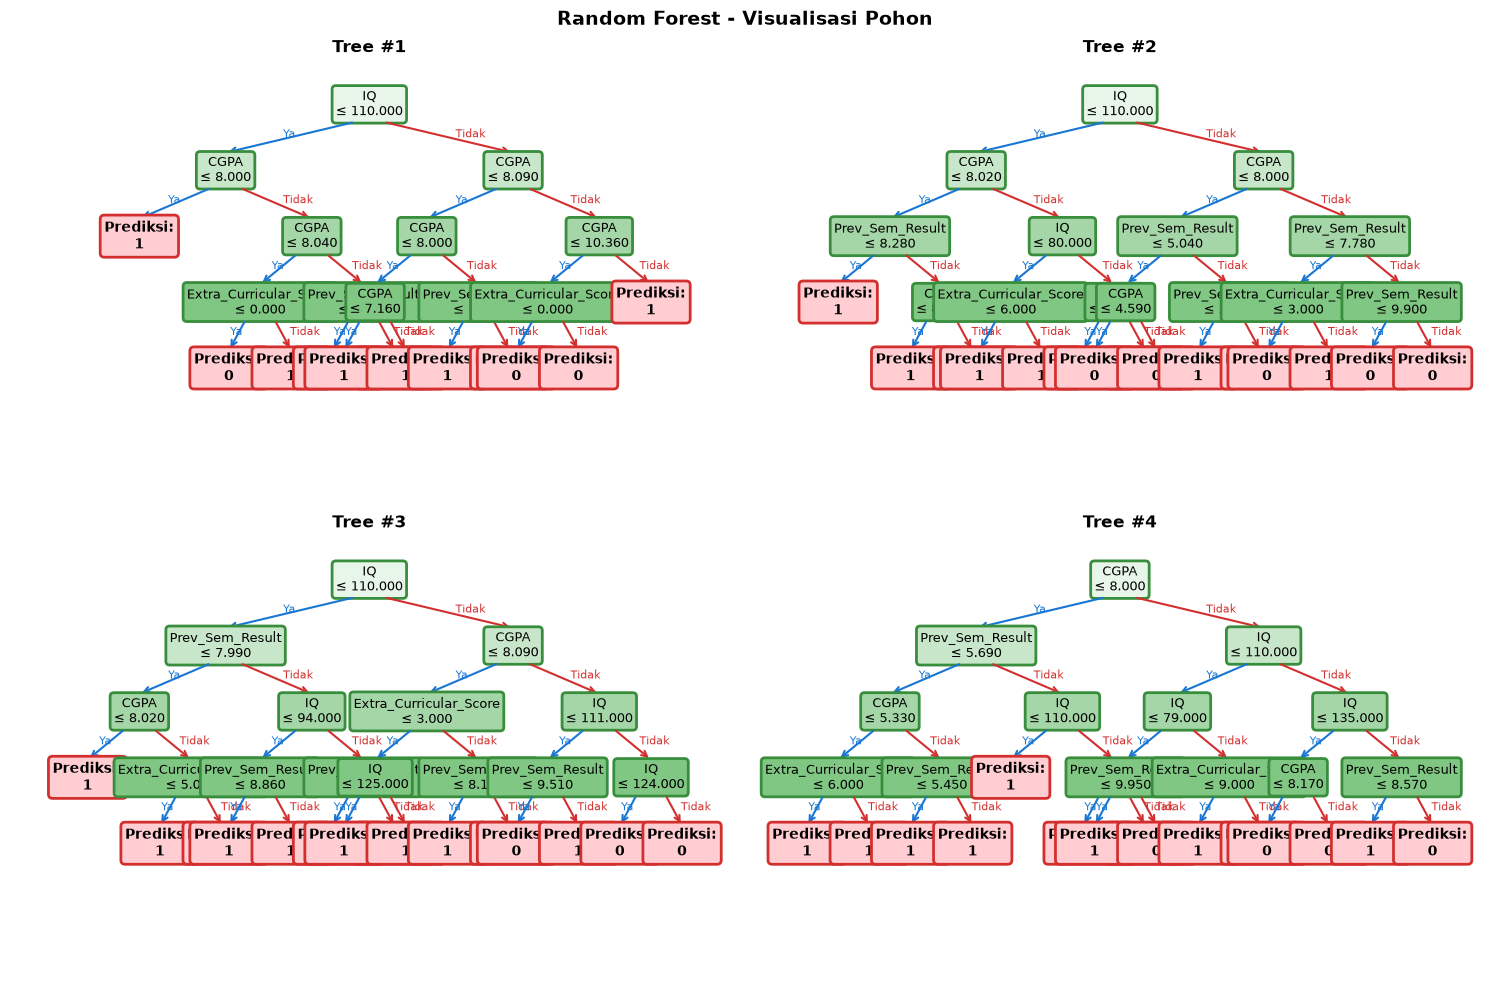

In [33]:
rf.visualize_all_trees(max_trees=4)

### 4. Tracing Path

In [34]:
rf.print_tree(0)


STRUKTUR TREE #1
📍 IQ <= 110.0000
├── Ya (kiri):
  📍 CGPA <= 8.0000
  ├── Ya (kiri):
    🍃 PREDIKSI: 1
  └── Tidak (kanan):
    📍 CGPA <= 8.0400
    ├── Ya (kiri):
      📍 Extra_Curricular_Score <= 0.0000
      ├── Ya (kiri):
        🍃 PREDIKSI: 0
      └── Tidak (kanan):
        🍃 PREDIKSI: 1
    └── Tidak (kanan):
      📍 Prev_Sem_Result <= 8.0400
      ├── Ya (kiri):
        🍃 PREDIKSI: 1
      └── Tidak (kanan):
        🍃 PREDIKSI: 1
└── Tidak (kanan):
  📍 CGPA <= 8.0900
  ├── Ya (kiri):
    📍 CGPA <= 8.0000
    ├── Ya (kiri):
      📍 CGPA <= 7.1600
      ├── Ya (kiri):
        🍃 PREDIKSI: 1
      └── Tidak (kanan):
        🍃 PREDIKSI: 1
    └── Tidak (kanan):
      📍 Prev_Sem_Result <= 7.6600
      ├── Ya (kiri):
        🍃 PREDIKSI: 1
      └── Tidak (kanan):
        🍃 PREDIKSI: 0
  └── Tidak (kanan):
    📍 CGPA <= 10.3600
    ├── Ya (kiri):
      📍 Extra_Curricular_Score <= 0.0000
      ├── Ya (kiri):
        🍃 PREDIKSI: 0
      └── Tidak (kanan):
        🍃 PREDIKSI: 0
    └── T

# ***C. Evaluasi Model***

### 1. Evaluation Metric

In [35]:
def evaluation_metric(y_true, y_pred, average):
    accuracy_list, precision_list, recall_list, f1_list = [], [], [], []
    labels = np.unique(y_true)

    for label in labels:
        TP = np.sum((y_true == label) & (y_pred == label))
        FP = np.sum((y_true != label) & (y_pred == label))

        TN = np.sum((y_true != label) & (y_pred != label))
        FN = np.sum((y_true == label) & (y_pred != label))

        accuracy = (TP + TN) / (TP + TN + FP + FN) * 100 if  (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if  (TP + FP)  != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

        accuracy_list.append(accuracy)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1_score)

    if average == 'macro':
        accuracy = np.mean(accuracy_list)
        precision = np.mean(precision_list)
        recall = np.mean(recall_list)
        f1_score = np.mean(f1_list)

    elif average == 'micro':
        TP = np.sum(y_true == y_pred)
        FP = np.sum((y_true != y_pred) & (y_pred != y_true))

        TN = np.sum(y_true == y_pred)
        FN = np.sum((y_true == y_pred) & (y_true != y_pred))

        accuracy = (TP + TN) /  (TP + TN + FP + FN) * 100 if  (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if  (TP + FP)  != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return accuracy, precision, recall, f1_score

#### *a. Training Model*

In [36]:
accuracy_forest_train, precision_forest_train, recall_forest_train, f1_score_forest_train = evaluation_metric(y_train, y_pred_train, average='micro')

print("-----------------------------------------------------------------")
print(f"Akurasi Random Forest Train: {accuracy_forest_train:.2f}")
print("-----------------------------------------------------------------")
print(f"Presisi Random Forest Train: {precision_forest_train:.2f}")
print("-----------------------------------------------------------------")
print(f"Recall Random Forest Train: {recall_forest_train:.2f}")
print("-----------------------------------------------------------------")
print(f"F1 Score Random Forest Train: {f1_score_forest_train:.2f}")
print("-----------------------------------------------------------------")

-----------------------------------------------------------------
Akurasi Random Forest Train: 94.01
-----------------------------------------------------------------
Presisi Random Forest Train: 0.89
-----------------------------------------------------------------
Recall Random Forest Train: 1.00
-----------------------------------------------------------------
F1 Score Random Forest Train: 0.94
-----------------------------------------------------------------


#### *b. Testing Model*

In [37]:
accuracy_forest_test, precision_forest_test, recall_forest_test, f1_score_forest_test = evaluation_metric(y_test ,y_pred_test, average='micro')

print("-----------------------------------------------------------------")
print(f"Akurasi Random Forest Test: {accuracy_forest_test:.2f}")
print("-----------------------------------------------------------------")
print(f"Presisi Random Forest Test: {precision_forest_test:.2f}")
print("-----------------------------------------------------------------")
print(f"Recall Random Forest Test: {recall_forest_test:.2f}")
print("-----------------------------------------------------------------")
print(f"F1 Score Random Forest Test: {f1_score_forest_test:.2f}")
print("-----------------------------------------------------------------")

-----------------------------------------------------------------
Akurasi Random Forest Test: 93.73
-----------------------------------------------------------------
Presisi Random Forest Test: 0.88
-----------------------------------------------------------------
Recall Random Forest Test: 1.00
-----------------------------------------------------------------
F1 Score Random Forest Test: 0.94
-----------------------------------------------------------------


### 2. Bias and Variance Model

In [38]:
bias = 100 - accuracy_forest_test
variance = accuracy_forest_train - accuracy_forest_test
data = {
    'Metric' : ['Bias', 'Variance'],
    'Value' : [bias, variance]
}

data_eval_forest = pd.DataFrame(data)

C:\Users\nizam\AppData\Local\Temp\ipykernel_11088\584593605.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_eval_forest, x='Metric', y='Value', palette='coolwarm')


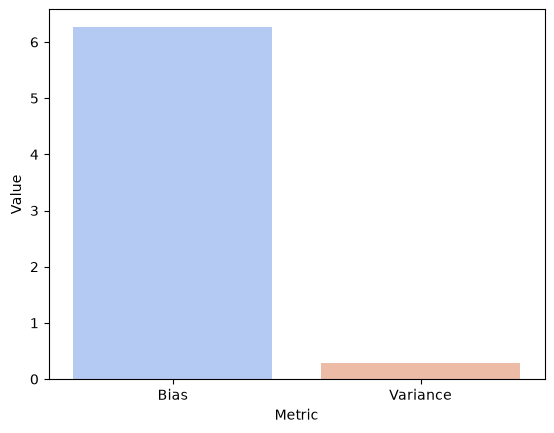

In [39]:
sns.barplot(data=data_eval_forest, x='Metric', y='Value', palette='coolwarm')
plt.show()

### 3. K-Fold

In [40]:
def accuracy_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)

def stratified_k_fold(X, y, model, k=5, random_state=42):
    np.random.seed(random_state)
    unique_classes, counts = np.unique(y, return_counts=True)
    class_indices = {cls: np.where(y == cls)[0] for cls in unique_classes}
    folds = [[] for _ in range(k)]

    for cls, indices in class_indices.items():
        np.random.shuffle(indices)
        fold_sizes = np.array_split(indices, k)
        for i in range(k):
            folds[i].extend(fold_sizes[i])

    accuracies = []

    for i in range(k):
        test_idx = np.array(folds[i])
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Latih model
        model.fit(X_train, y_train)
        # Prediksi
        y_pred = model.predict(X_test)

        # Akurasi manual
        accuracy = accuracy_manual(y_test, y_pred)
        accuracies.append(accuracy)

        print(f"Fold {i + 1}: Accuracy = {accuracy:.2f}")

    avg_acc = np.mean(accuracies)
    std_dev = np.std(accuracies)

    print(f"\nAverage Accuracy: {avg_acc:.2f}")
    print(f"Standard Deviation: {std_dev:.2f}")

    return avg_acc, std_dev

In [41]:
k_fold_forest_train = stratified_k_fold(X_test, y_test, rf, k=5)

Tree 5/15 selesai
Tree 10/15 selesai
Tree 15/15 selesai
Training selesai!
Fold 1: Accuracy = 0.88
Tree 5/15 selesai
Tree 10/15 selesai
Tree 15/15 selesai
Training selesai!
Fold 2: Accuracy = 0.86
Tree 5/15 selesai
Tree 10/15 selesai
Tree 15/15 selesai
Training selesai!
Fold 3: Accuracy = 0.89
Tree 5/15 selesai
Tree 10/15 selesai
Tree 15/15 selesai
Training selesai!
Fold 4: Accuracy = 0.89
Tree 5/15 selesai
Tree 10/15 selesai
Tree 15/15 selesai
Training selesai!
Fold 5: Accuracy = 0.89

Average Accuracy: 0.88
Standard Deviation: 0.01


# **IV. GUI**

In [42]:
root = tk.Tk()
root.title("Student Placement Predictor")
root.geometry("420x600")
root.configure(bg="#f5f5f5")

header = tk.Label(
    root, 
    text="Student Placement Prediction", 
    font=("Arial", 17, "bold"), 
    bg="#34495e", 
    fg="white", 
    pady=12
)
header.pack(fill="x")

main_frame = tk.Frame(root, bg="#f5f5f5", pady=30)
main_frame.pack()

# ============================
# ENTRY: NAMA (non-prediksi)
# ============================

name_label = tk.Label(main_frame, text="Nama", font=("Arial", 11, "bold"), bg="#f5f5f5")
name_label.grid(row=0, column=0, padx=10, pady=10, sticky="w")

name_entry = tk.Entry(main_frame, font=("Arial", 11), width=22)
name_entry.grid(row=0, column=1, padx=10, pady=10)

# ============================
# ENTRY untuk fitur numerik
# ============================

entry_vars = {}

for i, col in enumerate(feature_cols):
    label = tk.Label(main_frame, text=col, font=("Arial", 11, "bold"), bg="#f5f5f5")
    label.grid(row=i+1, column=0, padx=10, pady=10, sticky="w")

    var = tk.StringVar()
    entry = tk.Entry(main_frame, textvariable=var, font=("Arial", 11), width=22)
    entry.grid(row=i+1, column=1, padx=10, pady=10)

    entry_vars[col] = var

# ============================
# RESULT FRAME
# ============================

result_frame = tk.Frame(root, bg="#ecf0f1", relief="ridge", bd=2)
result_frame.pack(fill="x", padx=30, pady=20)

result_title = tk.Label(
    result_frame, text="Prediction Result", 
    font=("Arial", 12, "bold"), bg="#ecf0f1", fg="#2c3e50"
)
result_title.pack(pady=10)

result_label = tk.Label(
    result_frame, 
    text="Masukkan data lalu klik Predict", 
    font=("Arial", 11), 
    bg="#ecf0f1", fg="#7f8c8d", height=2
)
result_label.pack(pady=5)


# ============================
# FUNCTION: PREDICT
# ============================

def predict_student():
    try:
        # Ambil input user
        input_values = []
        for col in feature_cols:
            val = float(entry_vars[col].get())
            input_values.append(val)

        # Convert ke numpy array
        X_gui = np.array(input_values).reshape(1, -1)

        # Prediksi
        prediction = rf.predict(X_gui)[0]   # 0 atau 1

        # Tampilkan hasil
        if prediction == 1:
            result_label.config(
                text=f"LULUS PLACEMENT (YES)",
                fg="#27ae60",
                font=("Arial", 12, "bold")
            )
        else:
            result_label.config(
                text=f"TIDAK LULUS PLACEMENT (NO)",
                fg="#e74c3c",
                font=("Arial", 12, "bold")
            )

    except Exception as e:
        result_label.config(
            text=f"Error: {str(e)}",
            fg="#e74c3c"
        )


# ============================
# FUNCTION: RESET
# ============================

def reset_all():
    name_entry.delete(0, tk.END)
    for col in feature_cols:
        entry_vars[col].set("")
    result_label.config(
        text="Masukkan data lalu klik Predict",
        fg="#7f8c8d",
        font=("Arial", 11)
    )


# ============================
# BUTTONS
# ============================

button_frame = tk.Frame(root, bg="#f5f5f5")
button_frame.pack()

predict_btn = tk.Button(
    button_frame, text="PREDICT", command=predict_student,
    font=("Arial", 11, "bold"), bg="#3498db", fg="white",
    width=12, pady=8, cursor="hand2", relief="raised"
)
predict_btn.grid(row=0, column=0, padx=10)

reset_btn = tk.Button(
    button_frame, text="RESET", command=reset_all,
    font=("Arial", 11, "bold"), bg="#95a5a6", fg="white",
    width=12, pady=8, cursor="hand2", relief="raised"
)
reset_btn.grid(row=0, column=1, padx=10)

footer = tk.Label(root, text="SMKN 8 Malang", font=("Arial", 9), bg="#f5f5f5", fg="#95a5a6")
footer.pack(side="bottom", pady=10)

root.mainloop()
